# Chapter 5: Recurrent Neural Networks and Long Short-Term Memory

*Deep Learning Crash Course - BPB Publications*

This notebook implements a vanilla RNN from scratch, demonstrates the vanishing gradient problem, builds LSTM and GRU networks for IMDb sentiment analysis, and walks through tokenisation, padding, embeddings and temperature-controlled text generation.


## 1. Setup

In [1]:
import os
# CPU-mode guard: hide the GPU from TensorFlow before it is imported.
# Many machines have an NVIDIA driver but a missing CUDA toolkit
# (no `ptxas`), in which case TF's XLA JIT crashes the kernel. Remove
# these two lines once you have a complete CUDA install.
os.environ.setdefault('CUDA_VISIBLE_DEVICES', '-1')
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')
import random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

IMG_DIR = Path('images'); IMG_DIR.mkdir(exist_ok=True)
def set_seed(s=42):
    os.environ['PYTHONHASHSEED'] = str(s); random.seed(s); np.random.seed(s)
    try:
        import tensorflow as tf; tf.random.set_seed(s)
    except ModuleNotFoundError: pass
    try:
        import torch; torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    except ModuleNotFoundError: pass
set_seed(42)


## 2. Vanilla RNN forward pass from scratch

$h_t = \tanh(W_{xh} x_t + W_{hh} h_{t-1} + b_h)$. Same parameters used at every time step (parameter sharing).

In [2]:
class VanillaRNN:
    def __init__(self, input_size, hidden_size, seed=0):
        rng = np.random.default_rng(seed)
        self.W_xh = rng.standard_normal((input_size, hidden_size)) * 0.1
        self.W_hh = rng.standard_normal((hidden_size, hidden_size)) * 0.1
        self.b_h = np.zeros(hidden_size)

    def forward(self, X):
        """X: (T, input_size). Returns sequence of hidden states (T, hidden)."""
        T = X.shape[0]
        h = np.zeros(self.W_hh.shape[0])
        hs = []
        for t in range(T):
            h = np.tanh(X[t] @ self.W_xh + h @ self.W_hh + self.b_h)
            hs.append(h.copy())
        return np.array(hs)

rnn = VanillaRNN(input_size=4, hidden_size=8)
X = np.random.randn(6, 4)  # sequence of 6 tokens
out = rnn.forward(X)
print('Hidden states across time:', out.shape)


Hidden states across time: (6, 8)


## 3. Vanishing gradient demonstration

We multiply many copies of $\tanh'(z) \cdot W_{hh}$ and watch the gradient norm decay exponentially with depth.

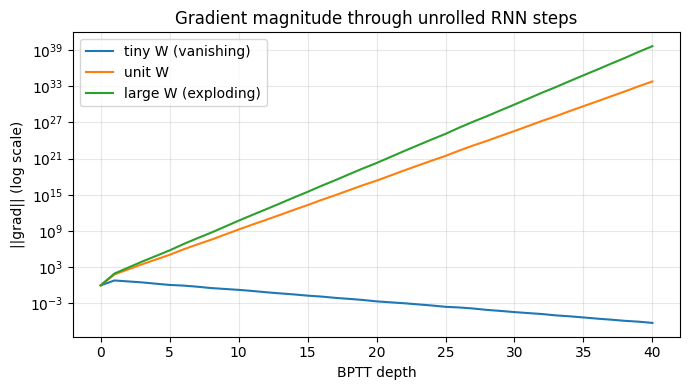

In [3]:
def vanishing_gradient_curve(T, W_scale):
    rng = np.random.default_rng(0)
    h = rng.standard_normal(64) * 0.5
    W = rng.standard_normal((64, 64)) * W_scale
    norms = [1.0]
    grad = np.ones_like(h)
    for _ in range(T):
        # gradient through tanh derivative * W^T
        local = 1 - np.tanh(h) ** 2
        grad = (local * grad) @ W.T
        norms.append(np.linalg.norm(grad))
    return np.array(norms)

fig, ax = plt.subplots(figsize=(7, 4))
for scale, label in [(0.1, 'tiny W (vanishing)'),
                     (1.0, 'unit W'),
                     (1.4, 'large W (exploding)')]:
    ax.plot(vanishing_gradient_curve(40, scale), label=f'{label}')
ax.set_xlabel('BPTT depth'); ax.set_ylabel('||grad|| (log scale)')
ax.set_yscale('log'); ax.legend(); ax.grid(alpha=0.3)
ax.set_title('Gradient magnitude through unrolled RNN steps')
fig.tight_layout(); fig.savefig(IMG_DIR / '01_vanishing_gradient.png', dpi=150); plt.show()


## 4. Text preprocessing: tokenise, vocab, pad

We build a small toy corpus to keep the cell fast; later we use the IMDb dataset.

In [4]:
import re
from collections import Counter

corpus = [
    'I loved the movie - it was breathtaking',
    'Boring and predictable plot.',
    'Beautiful cinematography but weak ending',
    'A masterpiece of modern cinema',
    'I would not recommend this to anyone',
]
tokens = [re.findall(r"\w+", s.lower()) for s in corpus]
counter = Counter(t for s in tokens for t in s)
vocab = {'<pad>': 0, '<unk>': 1}
for word, _ in counter.most_common(): vocab[word] = len(vocab)
print('Vocab:', vocab)

def encode(seq, max_len=8):
    ids = [vocab.get(w, 1) for w in seq][:max_len]
    return ids + [0] * (max_len - len(ids))

encoded = np.array([encode(s) for s in tokens])
print('Encoded shape:', encoded.shape)
print(encoded)


Vocab: {'<pad>': 0, '<unk>': 1, 'i': 2, 'loved': 3, 'the': 4, 'movie': 5, 'it': 6, 'was': 7, 'breathtaking': 8, 'boring': 9, 'and': 10, 'predictable': 11, 'plot': 12, 'beautiful': 13, 'cinematography': 14, 'but': 15, 'weak': 16, 'ending': 17, 'a': 18, 'masterpiece': 19, 'of': 20, 'modern': 21, 'cinema': 22, 'would': 23, 'not': 24, 'recommend': 25, 'this': 26, 'to': 27, 'anyone': 28}
Encoded shape: (5, 8)
[[ 2  3  4  5  6  7  8  0]
 [ 9 10 11 12  0  0  0  0]
 [13 14 15 16 17  0  0  0]
 [18 19 20 21 22  0  0  0]
 [ 2 23 24 25 26 27 28  0]]


## 5. LSTM for IMDb sentiment classification (Keras)

In [5]:
import tensorflow as tf
VOCAB_SIZE = 10000; MAX_LEN = 200
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.imdb.load_data(num_words=VOCAB_SIZE)
x_train = tf.keras.preprocessing.sequence.pad_sequences(x_train, maxlen=MAX_LEN, padding='post')
x_test  = tf.keras.preprocessing.sequence.pad_sequences(x_test,  maxlen=MAX_LEN, padding='post')
print('IMDb train:', x_train.shape, 'test:', x_test.shape)


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
IMDb train: (25000, 200) test: (25000, 200)


In [6]:
def build_lstm(units=64, embed=64, bidirectional=True):
    layers = [
        tf.keras.layers.Embedding(VOCAB_SIZE, embed, mask_zero=True),
        tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(units)) if bidirectional
          else tf.keras.layers.LSTM(units),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(1, activation='sigmoid'),
    ]
    return tf.keras.Sequential(layers)

set_seed(0)
lstm = build_lstm()
lstm.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
h = lstm.fit(x_train, y_train, validation_split=0.1, epochs=3, batch_size=128, verbose=2)
print('Test:', lstm.evaluate(x_test, y_test, verbose=0))


Epoch 1/3


2026-05-16 19:07:31.731674: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2026-05-16 19:07:35.519104: E tensorflow/core/util/util.cc:131] oneDNN supports DT_BOOL only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


176/176 - 121s - 687ms/step - accuracy: 0.7847 - loss: 0.4416 - val_accuracy: 0.8744 - val_loss: 0.3238
Epoch 2/3
176/176 - 118s - 672ms/step - accuracy: 0.9060 - loss: 0.2448 - val_accuracy: 0.8720 - val_loss: 0.3051
Epoch 3/3
176/176 - 117s - 665ms/step - accuracy: 0.9256 - loss: 0.2017 - val_accuracy: 0.8340 - val_loss: 0.4472
Test: [0.4661335051059723, 0.8226000070571899]


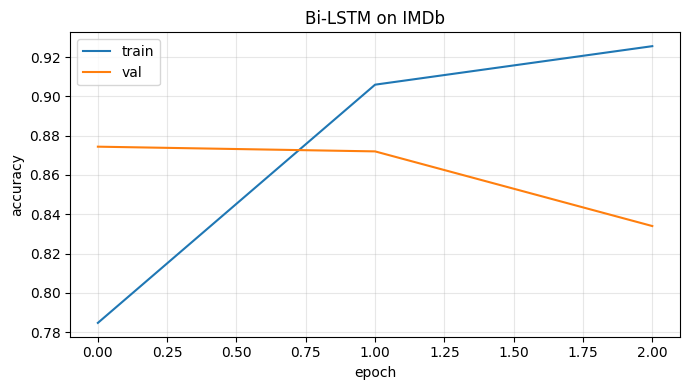

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(h.history['accuracy'], label='train'); ax.plot(h.history['val_accuracy'], label='val')
ax.set_xlabel('epoch'); ax.set_ylabel('accuracy'); ax.legend(); ax.grid(alpha=0.3)
ax.set_title('Bi-LSTM on IMDb')
fig.tight_layout(); fig.savefig(IMG_DIR / '02_bilstm_imdb.png', dpi=150); plt.show()


## 6. GRU comparison in PyTorch

The GRU achieves comparable accuracy with ~25 percent fewer parameters than the LSTM.

In [8]:
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    set_seed(0)
    train_ds = TensorDataset(torch.tensor(x_train), torch.tensor(y_train).float())
    test_ds  = TensorDataset(torch.tensor(x_test),  torch.tensor(y_test).float())
    train_dl = DataLoader(train_ds, batch_size=128, shuffle=True)
    test_dl  = DataLoader(test_ds, batch_size=256)

    class GRUClassifier(nn.Module):
        def __init__(self, vocab=VOCAB_SIZE, embed=64, hidden=64):
            super().__init__()
            self.emb = nn.Embedding(vocab, embed, padding_idx=0)
            self.gru = nn.GRU(embed, hidden, batch_first=True, bidirectional=True)
            self.fc  = nn.Sequential(nn.Linear(hidden * 2, 32), nn.ReLU(), nn.Linear(32, 1))
        def forward(self, x):
            e = self.emb(x)
            _, h = self.gru(e)
            h = torch.cat([h[0], h[1]], dim=1)
            return self.fc(h).squeeze(-1)

    net = GRUClassifier().to(device)
    opt = torch.optim.Adam(net.parameters(), lr=1e-3)
    loss_fn = nn.BCEWithLogitsLoss()
    for epoch in range(2):
        net.train(); total = 0
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(); out = net(xb); loss = loss_fn(out, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(net.parameters(), 1.0)
            opt.step(); total += loss.item() * xb.size(0)
        # Eval
        net.eval(); correct = 0
        with torch.no_grad():
            for xb, yb in test_dl:
                xb, yb = xb.to(device), yb.to(device)
                pred = (torch.sigmoid(net(xb)) > 0.5).long()
                correct += (pred == yb.long()).sum().item()
        print(f'Epoch {epoch+1} | train loss {total/len(train_ds):.4f} | test acc {correct/len(test_ds):.4f}')
except ModuleNotFoundError:
    print('PyTorch not installed - skipping.')


Epoch 1 | train loss 0.6671 | test acc 0.6927
Epoch 2 | train loss 0.5115 | test acc 0.7790


## 7. Temperature-controlled text generation

We define a sampling utility that can be reused for any next-token distribution.

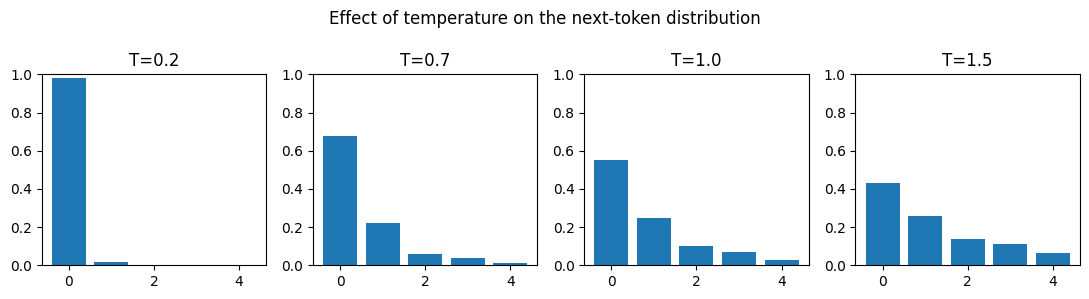

T=0.2: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
T=1.0: [4, 1, 0, 1, 0, 1, 0, 3, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 3, 1]
T=1.5: [0, 1, 2, 0, 1, 1, 0, 0, 0, 0, 1, 1, 4, 0, 0, 0, 1, 0, 1, 0]


In [9]:
def sample_with_temperature(probs, temperature=1.0):
    if temperature == 0.0:
        return int(np.argmax(probs))
    logits = np.log(np.maximum(probs, 1e-12))
    logits = logits / temperature
    z = np.exp(logits - logits.max())
    p = z / z.sum()
    return int(np.random.choice(len(p), p=p))

# Toy distribution: 5 candidate tokens
probs = np.array([0.55, 0.25, 0.10, 0.07, 0.03])
fig, axes = plt.subplots(1, 4, figsize=(11, 3))
for ax, T in zip(axes, [0.2, 0.7, 1.0, 1.5]):
    # Reshape softmax with temperature
    L = np.log(probs) / T
    p = np.exp(L - L.max()); p /= p.sum()
    ax.bar(range(len(p)), p); ax.set_title(f'T={T}'); ax.set_ylim(0, 1)
fig.suptitle('Effect of temperature on the next-token distribution')
fig.tight_layout(); fig.savefig(IMG_DIR / '03_temperature.png', dpi=150); plt.show()

set_seed(0)
for T in [0.2, 1.0, 1.5]:
    draws = [sample_with_temperature(probs, T) for _ in range(20)]
    print(f'T={T}: {draws}')


## 8. Exercise solutions

### 8.1 MCQ answers

| Q | Answer | Why |
|---|--------|-----|
| 1 | (b) Hidden state carries info across time steps | The defining property of RNNs. |
| 2 | (c) Parameter sharing | Same weights at every step. |
| 3 | (b) Repeated multiplication of W_hh and small tanh derivatives | Product < 1 per step decays exponentially. |
| 4 | (c) Forget gate | Controls what flows out of the cell state. |
| 5 | (b) Additive cell state update preserves gradient flow | Constant Error Carousel. |
| 6 | (c) GRU has 2, LSTM has 3 | Update + reset vs forget + input + output. |
| 7 | (c) Fill short sequences to a uniform length | Enables batching of variable-length sequences. |
| 8 | (b) Maps integer word indices to dense low-dim vectors | Learned lookup table. |
| 9 | (c) Backward pass that gives access to future context | Useful for classification, not generation. |
| 10 | (b) Diversity of generated text | Low T -> greedy, high T -> uniform. |
| 11 | (c) Gradient clipping | Caps the norm of the gradient. |
| 12 | (b) Real-time streaming data, very long sequences or edge devices | RNNs still excel at causal streaming. |


### 8.2 Trace of a vanilla RNN on a 3-token sequence with hidden size 4
Inputs: `['hello', 'world', '!']` mapped to embedding vectors $x_1, x_2, x_3 \in \mathbb{R}^E$.
- $h_0 = \mathbf{0} \in \mathbb{R}^4$
- $h_1 = \tanh(W_{xh} x_1 + W_{hh} h_0 + b_h) \in \mathbb{R}^4$
- $h_2 = \tanh(W_{xh} x_2 + W_{hh} h_1 + b_h) \in \mathbb{R}^4$
- $h_3 = \tanh(W_{xh} x_3 + W_{hh} h_2 + b_h) \in \mathbb{R}^4$

$x_t$ shape: $E$; $W_{xh}$: $E \times 4$; $W_{hh}$: $4 \times 4$; output: $4$.
$h_t$ summarises everything the network has seen so far - its content evolves as new tokens are observed.

In [10]:
# Mini-demo of the trace
rng = np.random.default_rng(0)
E = 5
x = rng.standard_normal((3, E))
rnn2 = VanillaRNN(input_size=E, hidden_size=4)
hs = rnn2.forward(x)
for t in range(3):
    print(f'h{t+1} =', hs[t])


h1 = [-0.03163629 -0.07270166 -0.08401125 -0.07194709]
h2 = [ 0.09904143 -0.0327839   0.18215204  0.05554907]
h3 = [ 0.25316625  0.35257243  0.0649201  -0.12083871]


### 8.3 Mathematical reason gradients vanish during BPTT
Unrolling the RNN for $T$ steps and computing $\partial L / \partial h_t$ produces $\prod_{k=t+1}^{T} \text{diag}(1 - \tanh^2(z_k)) W_{hh}^T$. The diagonal entries are always between 0 and 1, and the spectral radius of $W_{hh}$ is rarely exactly 1, so the product is either contracting or expanding. For random initialisations the common case is contraction, and after $\sim 20-50$ steps the gradient has fallen below machine epsilon.

### 8.4 LSTM forget gate vs GRU update gate
Both gates decide how much of the previous state to keep. The LSTM forget gate $f_t$ scalar-multiplies the *cell state* $c_{t-1}$ before adding the input gate term. The GRU update gate $z_t$ interpolates between the previous hidden state and the candidate state $\tilde{h}_t$: $h_t = (1 - z_t) h_{t-1} + z_t \tilde{h}_t$. The LSTM has separate forget and input gates - two independent decisions - while the GRU couples them into one $z_t$. The LSTM also exposes a separate *output gate* on the cell state, which the GRU lacks.

### 8.5 95% train vs 72% test on an LSTM sentiment classifier
Classic over-fitting. Four mitigations:
1. **Recurrent dropout** (`dropout=` and `recurrent_dropout=` in Keras LSTM, or `nn.LSTM(..., dropout=...)` between stacked layers in PyTorch).
2. **L2 weight decay** on the dense layers.
3. **Reduce model capacity** - hidden size 64 to 128 is plenty for IMDb.
4. **Pre-trained word embeddings** (GloVe, fastText, or a small BERT). Lots of vocabulary words appear too rarely to learn good embeddings from scratch.


### 8.6 End-to-end pipeline for 5,000 customer-support emails (8 classes)
1. **Tokenise** with a sentencepiece or BPE tokenizer (handles ticket-specific vocabulary like `case#1234`).
2. **Build vocab** from training data, cap at 20,000 tokens, set `<unk>` and `<pad>`.
3. **Length**: 95th percentile of training lengths -> set `max_len = 180`.
4. **Class imbalance**: weight loss by inverse class frequency or oversample minority classes.
5. **Architecture**: 200-d embedding -> bidirectional GRU (hidden 128) -> mean-pooling -> 8-way softmax.
6. **Training**: 80/10/10 split, Adam $10^{-3}$, batch 32, gradient clip 1.0, early stop on val macro-F1.
7. **Evaluation**: macro-F1 (so rare classes count), per-class confusion matrix, model card noting failure modes.


### 8.7 Bi-LSTM for sentiment but not for generation
Sentiment classification consumes the whole sequence first and then produces one label, so peeking at future tokens is fine. Generation produces one token at a time and the future has not yet been seen, so a model that depends on future context cannot be used auto-regressively. Bidirectional models are appropriate when the *full* input is available at inference time; otherwise, stick to a causal (left-to-right) model.

### 8.8 Temperature-based sampling
Already implemented in section 7. As $T \to 0$, the softmax becomes a one-hot at the argmax -> deterministic greedy decoding. As $T \to \infty$, the softmax becomes uniform over the vocabulary -> random gibberish. A value of $T \approx 0.7$-$1.0$ is a good default for natural-text generation.

---
*End of Chapter 5.*
